In [ ]:
import transformers
import torch
import sklearn.decomposition
import PIL.Image
import numpy as np
import matplotlib
from torch import Tensor

# Define util functions

In [ ]:
def pca(embs: Tensor, low_dim: int) -> Tensor:
    pca = sklearn.decomposition.PCA(n_components=low_dim)
    reduced_embs = pca.fit_transform(embs.detach().numpy())
    return torch.tensor(reduced_embs)

def fourier(embs: Tensor) -> Tensor:
    return torch.fft.fft(embs, dim=0)

def vis_emb(embs: Tensor, colorful: bool) -> PIL.Image.Image:
    x = embs.cpu().detach()
    x_normalized = (x - x.min()) / (x.max() - x.min())
    theme = matplotlib.colormaps["Blues"]
    if colorful:
        x_normalized = theme(x_normalized)
    else:
        x_normalized = x_normalized.numpy()
    vis = PIL.Image.fromarray((x_normalized * 255).astype(np.uint8))
    return vis


# Load the model

In [ ]:
model_ckpt = "meta-llama/Llama-3.2-1B"

In [ ]:
model = transformers.AutoModelForCausalLM.from_pretrained(model_ckpt).eval()
tokenizer = transformers.AutoTokenizer.from_pretrained(model_ckpt)

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

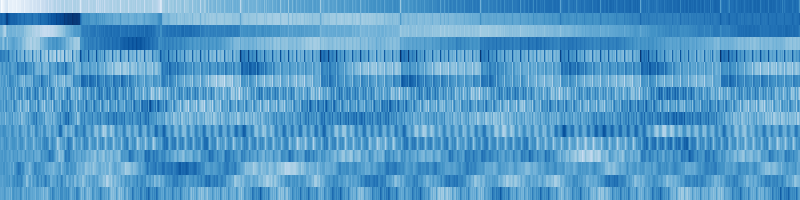

In [8]:
input_ids = tokenizer([str(i) for i in range(1000)], return_tensors="pt", add_special_tokens=False).input_ids.flatten()
embs = model.model.embed_tokens(input_ids).float().detach()
vis_emb(pca(embs, 16).T, colorful=True).resize((800, 200), PIL.Image.NEAREST)

# Define the probe

In [4]:
class ProbeSinParam(torch.nn.Module):
    def __init__(self, emb_dim: int, hidden_dim: int, choices: torch.Tensor, heldout_mask: torch.Tensor):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.emb_to_latent = torch.nn.Linear(emb_dim, hidden_dim, bias=True)
        self.freqs = torch.nn.Parameter(torch.linspace(1/(choices.max() - choices.min()), 0.5, steps=hidden_dim))
        self.phases = torch.nn.Parameter(torch.zeros(hidden_dim))
        self.amplitudes = torch.nn.Parameter(torch.ones(hidden_dim) * 0.0001)
        self.heldout_mask = torch.nn.Buffer(heldout_mask)
        self.choices = torch.nn.Buffer(choices)

    def get_waves(self) -> Tensor:
        waves = torch.sin(
            self.phases.unsqueeze(1)
            + (2 * torch.pi * self.freqs.unsqueeze(1) * self.choices.unsqueeze(0))
        )
        return waves * self.amplitudes.unsqueeze(1)

    def forward(self, x: Tensor, holdout_eval_tokens: bool) -> Tensor:
        latent_x = self.emb_to_latent(x)
        waves = self.get_waves()
        logits = latent_x @ waves

        # during training, model learns to choose among only training tokens
        # but during eval, model must choose among all tokens
        # this means that the model is never exposed to the eval tokens during training
        if holdout_eval_tokens:
            logits[:, self.heldout_mask] = -torch.inf

        return logits

# Train the probe

In [28]:
torch.manual_seed(0)
targets = torch.arange(1000)
heldout_mask = torch.rand(1000) < 0.1  # hold out for validation
probe = ProbeSinParam(emb_dim=embs.shape[-1], hidden_dim=2048, choices=targets, heldout_mask=heldout_mask)
optim = torch.optim.Adam(probe.parameters(), lr=1e-4)

for i in range(10001):
    optim.zero_grad()
    logits = probe(embs[~heldout_mask], holdout_eval_tokens=True)
    train_acc = (logits.argmax(dim=-1) == targets[~heldout_mask]).float().mean()

    loss = torch.nn.functional.cross_entropy(logits, targets[~heldout_mask])
    # l1 regularization on amplitudes to encourage sparsity
    loss += 0.001 * probe.amplitudes.abs().sum()
    # l2 regularization on w_in
    loss += 0.001 * probe.emb_to_latent.weight.pow(2).sum()

    loss.backward()
    optim.step()

    if i % 1000 == 0:
        valid_logits = probe(embs[heldout_mask], holdout_eval_tokens=False)
        valid_acc = (valid_logits.argmax(dim=-1) == targets[heldout_mask]).float().mean()
        print(f"Step {i:4d}, loss {loss.item():.4f}, train acc {train_acc.item():.4f}, valid acc {valid_acc.item():.4f}")


Step    0, loss 7.4856, train acc 0.0000, valid acc 0.0000


Step 1000, loss 6.2865, train acc 0.6556, valid acc 0.4300
Step 2000, loss 5.3227, train acc 0.6911, valid acc 0.5200
Step 3000, loss 4.4454, train acc 0.8300, valid acc 0.7100
Step 4000, loss 3.7344, train acc 0.9911, valid acc 0.9800
Step 5000, loss 3.1416, train acc 0.9967, valid acc 0.9900
Step 6000, loss 2.6074, train acc 0.9967, valid acc 0.9900
Step 7000, loss 2.2129, train acc 0.9989, valid acc 0.9900
Step 8000, loss 1.9118, train acc 1.0000, valid acc 0.9900
Step 9000, loss 1.6793, train acc 1.0000, valid acc 1.0000
Step 10000, loss 1.4912, train acc 1.0000, valid acc 1.0000


# Visualize the probe's latent pattern

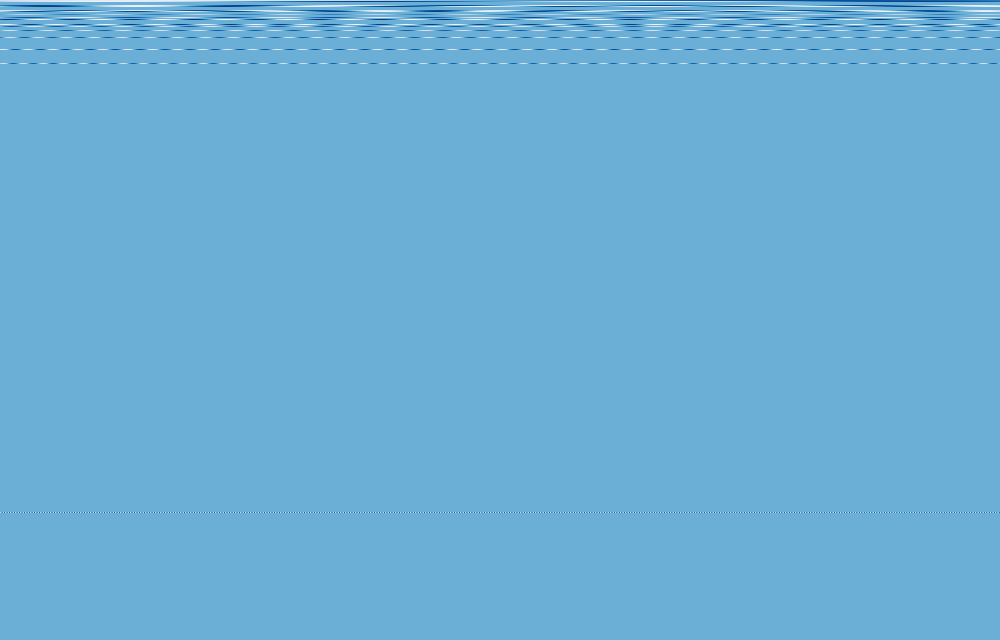

In [30]:
waves = probe.get_waves()
vis_emb(waves, colorful=True).resize((1000, 640), PIL.Image.NEAREST)

It's very sparse - thanks to L1 regularization of amplitudes.
Let's look at the nonzero features.

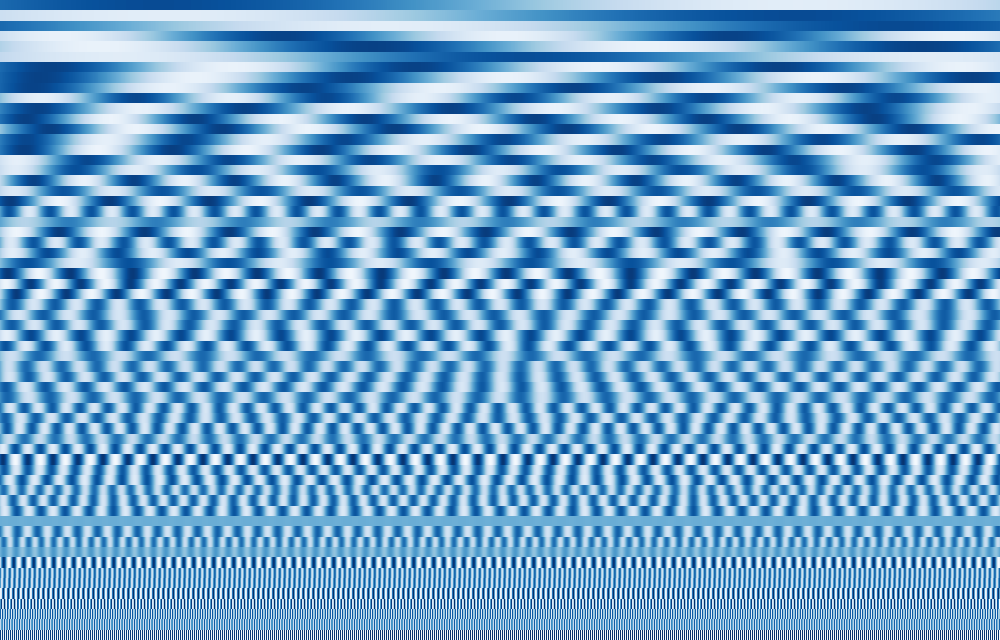

In [38]:
vis_emb(waves[(waves.abs() > 0.001).any(dim=1)], colorful=True).resize((1000, 640), PIL.Image.NEAREST)